# Computer Vision Homework 3: MLP 구성 요소 비교 실험

## 실험 목표

동일한 MLP 분류 문제에서 다음 세 요소를 하나씩 바꾸어 학습 결과에 미치는 영향을 정량적으로 비교한다.

- **실험 A**: 손실 함수 비교 - `CrossEntropyLoss` vs `MSELoss` with `softmax`
- **실험 B**: 활성화 함수 비교 - `ReLU` vs `LeakyReLU` vs `Sigmoid`
- **실험 C**: 최적화 알고리즘 및 학습률 비교 - `SGD` vs `SGD+Momentum` vs `Adam`

## Colab 실행 안내

1. Colab에서 `런타임 > 런타임 유형 변경 > T4 GPU`를 선택한다.
2. 이 노트북의 셀을 위에서부터 순서대로 실행한다.
3. 결과 표와 그림이 생성된 뒤, 각 실험 아래의 **실행 후 결과 분석** Markdown 셀을 직접 작성한다.

이 노트북은 실행 전 결론을 미리 작성하지 않고, 실행 결과가 생성된 후 보고서를 완성하도록 구성되어 있다.

## 0. 공통 실험 원칙

- PyTorch의 `nn.Module` 모델과 직접 작성한 `for epoch in range(...)` 학습 루프를 사용한다.
- 각 조건의 비교에서는 데이터 분할, 미니배치 순서, 초기 가중치를 고정하여 변경 대상 이외의 영향을 줄인다.
- 학습 중에는 validation set으로 곡선을 관찰하고, official test set은 각 조건 학습 종료 후 최종 평가에만 사용한다.
- 모든 평가 함수는 `model.eval()`과 `with torch.no_grad()`를 사용한다.
- Fashion-MNIST 실험은 Colab 실행 시간을 줄이기 위해 훈련/검증 subset을 사용하며, 최종 평가는 전체 test set에서 수행한다.

In [1]:
# 공통 라이브러리 및 재현성 설정
import copy
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sns.set_theme(style='whitegrid')
print('device:', device)
print('torch version:', torch.__version__)

device: cuda
torch version: 2.10.0+cu128


## 1. Fashion-MNIST 데이터와 공통 MLP

실험 A와 C는 Fashion-MNIST를 공유한다. 모델 구조는 `784 -> 256 -> 128 -> 10`이며 ReLU를 사용한다. 학습용 `12,000`개와 검증용 `3,000`개는 원래 train set에서 seed를 고정하여 선택하고, 최종 테스트는 official test set `10,000`개 전체로 수행한다.

In [2]:
FASHION_TRAIN_SIZE = 12000
FASHION_VAL_SIZE = 3000
FASHION_BATCH_SIZE = 128

fashion_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

fashion_full_train = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=fashion_transform
)
fashion_test_set = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=fashion_transform
)

split_generator = torch.Generator().manual_seed(SEED)
permuted_indices = torch.randperm(len(fashion_full_train), generator=split_generator).tolist()
fashion_train_set = Subset(fashion_full_train, permuted_indices[:FASHION_TRAIN_SIZE])
fashion_val_set = Subset(
    fashion_full_train,
    permuted_indices[FASHION_TRAIN_SIZE:FASHION_TRAIN_SIZE + FASHION_VAL_SIZE]
)

def make_fashion_loaders(shuffle_seed=SEED):
    loader_generator = torch.Generator().manual_seed(shuffle_seed)
    use_pin_memory = torch.cuda.is_available()
    train_loader = DataLoader(
        fashion_train_set, batch_size=FASHION_BATCH_SIZE, shuffle=True,
        generator=loader_generator, pin_memory=use_pin_memory
    )
    val_loader = DataLoader(
        fashion_val_set, batch_size=FASHION_BATCH_SIZE, shuffle=False,
        pin_memory=use_pin_memory
    )
    test_loader = DataLoader(
        fashion_test_set, batch_size=FASHION_BATCH_SIZE, shuffle=False,
        pin_memory=use_pin_memory
    )
    return train_loader, val_loader, test_loader

class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

set_seed()
fashion_initial_state = copy.deepcopy(FashionMLP().state_dict())
print('Fashion-MNIST split:', len(fashion_train_set), len(fashion_val_set), len(fashion_test_set))
print(FashionMLP())

100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.28MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 63.7MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 45.7MB/s]


Fashion-MNIST split: 12000 3000 10000
FashionMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 2. 공통 학습 및 평가 함수

실험 A와 C에서 같은 학습 루프를 사용한다. `loss_kind='mse'`인 경우에만 모델 출력에 `softmax`를 명시적으로 적용하고 정답을 one-hot 벡터로 변환한다. Gradient 흐름 비교를 위해 epoch별 평균 gradient L2 norm도 저장한다.

In [3]:
def classification_loss(logits, targets, criterion, loss_kind):
    if loss_kind == 'mse':
        probabilities = torch.softmax(logits, dim=1)
        one_hot_targets = F.one_hot(targets, num_classes=10).float()
        return criterion(probabilities, one_hot_targets)
    return criterion(logits, targets)

def gradient_l2_norm(model):
    squared_norm = 0.0
    for parameter in model.parameters():
        if parameter.grad is not None:
            squared_norm += parameter.grad.detach().pow(2).sum().item()
    return squared_norm ** 0.5

def module_gradient_l2_norm(module):
    squared_norm = 0.0
    for parameter in module.parameters():
        if parameter.grad is not None:
            squared_norm += parameter.grad.detach().pow(2).sum().item()
    return squared_norm ** 0.5

def evaluate_fashion_model(model, data_loader, criterion, loss_kind):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            logits = model(inputs)
            loss = classification_loss(logits, targets, criterion, loss_kind)
            running_loss += loss.item() * targets.size(0)
            correct += (logits.argmax(dim=1) == targets).sum().item()
            total += targets.size(0)
    return {'loss': running_loss / total, 'accuracy': 100.0 * correct / total}

def train_fashion_condition(model, train_loader, val_loader, criterion, loss_kind,
                            optimizer, epochs, scheduler=None, print_every=5):
    tracked_layers = {
        'grad_hidden_1': model.net[1],
        'grad_hidden_2': model.net[3],
        'grad_output': model.net[5]
    }
    history = {
        'epoch': [], 'lr': [], 'train_loss': [], 'train_accuracy': [],
        'val_loss': [], 'val_accuracy': [], 'gradient_norm': [],
        'grad_hidden_1': [], 'grad_hidden_2': [], 'grad_output': []
    }
    model.to(device)
    for epoch in range(1, epochs + 1):
        model.train()
        current_lr = optimizer.param_groups[0]['lr']
        running_loss = 0.0
        running_grad_norm = 0.0
        layer_grad_norms = {name: 0.0 for name in tracked_layers}
        correct = 0
        total = 0

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            optimizer.zero_grad()
            logits = model(inputs)
            loss = classification_loss(logits, targets, criterion, loss_kind)
            loss.backward()
            batch_size = targets.size(0)
            running_grad_norm += gradient_l2_norm(model) * batch_size
            for layer_name, layer in tracked_layers.items():
                layer_grad_norms[layer_name] += module_gradient_l2_norm(layer) * batch_size
            optimizer.step()

            running_loss += loss.item() * batch_size
            correct += (logits.argmax(dim=1) == targets).sum().item()
            total += batch_size

        validation = evaluate_fashion_model(model, val_loader, criterion, loss_kind)
        history['epoch'].append(epoch)
        history['lr'].append(current_lr)
        history['train_loss'].append(running_loss / total)
        history['train_accuracy'].append(100.0 * correct / total)
        history['val_loss'].append(validation['loss'])
        history['val_accuracy'].append(validation['accuracy'])
        history['gradient_norm'].append(running_grad_norm / total)
        for layer_name in tracked_layers:
            history[layer_name].append(layer_grad_norms[layer_name] / total)

        if scheduler is not None:
            scheduler.step()
        if epoch == 1 or epoch % print_every == 0 or epoch == epochs:
            print(
                f'Epoch {epoch:>2}/{epochs} | lr={current_lr:.5f} | '
                f'train loss={history["train_loss"][-1]:.4f} | '
                f'val acc={validation["accuracy"]:.2f}%'
            )
    return pd.DataFrame(history)

def first_epoch_reaching(values, threshold):
    reached = np.flatnonzero(np.asarray(values) >= threshold)
    return int(reached[0] + 1) if len(reached) else np.nan

# 실험 A. 손실 함수 비교: CrossEntropy Loss vs MSE Loss with Softmax

## 실험 조건

- 데이터셋: Fashion-MNIST
- 네트워크: 동일한 `FashionMLP` (`784 -> 256 -> 128 -> 10`, ReLU)
- 고정 요소: 동일 초기 가중치, 동일 mini-batch 순서, 동일 optimizer `Adam(lr=0.001)`, `30` epochs
- 변경 요소: `nn.CrossEntropyLoss()`와 `nn.MSELoss()`
- MSE 조건: `torch.softmax(logits, dim=1)` 및 one-hot target을 명시적으로 사용

`CrossEntropyLoss`와 `MSELoss`는 손실의 스케일 자체가 다르므로 loss 절대값만 직접 비교하지 않고, 정확도 수렴 속도와 gradient norm을 함께 확인한다.

In [4]:
A_EPOCHS = 30
A_LEARNING_RATE = 0.001

a_conditions = {
    'CrossEntropy': {'criterion': nn.CrossEntropyLoss(), 'loss_kind': 'ce'},
    'MSE + Softmax': {'criterion': nn.MSELoss(), 'loss_kind': 'mse'}
}
a_histories = {}
a_test_results = {}

for condition_name, configuration in a_conditions.items():
    print(f'\n[A] Training: {condition_name}')
    train_loader, val_loader, test_loader = make_fashion_loaders(shuffle_seed=SEED)
    model = FashionMLP().to(device)
    model.load_state_dict(copy.deepcopy(fashion_initial_state))
    optimizer = optim.Adam(model.parameters(), lr=A_LEARNING_RATE)
    history = train_fashion_condition(
        model, train_loader, val_loader,
        configuration['criterion'], configuration['loss_kind'],
        optimizer, epochs=A_EPOCHS
    )
    test_metrics = evaluate_fashion_model(
        model, test_loader, configuration['criterion'], configuration['loss_kind']
    )
    a_histories[condition_name] = history
    a_test_results[condition_name] = test_metrics

a_summary_rows = []
for condition_name, history in a_histories.items():
    a_summary_rows.append({
        'Loss Function': condition_name,
        'Best Validation Accuracy (%)': history['val_accuracy'].max(),
        'Best Validation Epoch': int(history.loc[history['val_accuracy'].idxmax(), 'epoch']),
        'Minimum Validation Loss': history['val_loss'].min(),
        'Epoch at Minimum Validation Loss': int(history.loc[history['val_loss'].idxmin(), 'epoch']),
        'Epoch Reaching 80% Validation Accuracy': first_epoch_reaching(history['val_accuracy'], 80.0),
        'Final Test Accuracy (%)': a_test_results[condition_name]['accuracy'],
        'Final Test Loss': a_test_results[condition_name]['loss'],
        'Final Gradient Norm': history['gradient_norm'].iloc[-1]
    })

a_summary = pd.DataFrame(a_summary_rows).round(4)
display(a_summary)


[A] Training: CrossEntropy
Epoch  1/30 | lr=0.00100 | train loss=0.7925 | val acc=80.23%
Epoch  5/30 | lr=0.00100 | train loss=0.3665 | val acc=85.37%
Epoch 10/30 | lr=0.00100 | train loss=0.2722 | val acc=85.30%
Epoch 15/30 | lr=0.00100 | train loss=0.2077 | val acc=85.53%
Epoch 20/30 | lr=0.00100 | train loss=0.1458 | val acc=86.27%
Epoch 25/30 | lr=0.00100 | train loss=0.1017 | val acc=85.57%
Epoch 30/30 | lr=0.00100 | train loss=0.0974 | val acc=85.63%

[A] Training: MSE + Softmax
Epoch  1/30 | lr=0.00100 | train loss=0.0387 | val acc=79.47%
Epoch  5/30 | lr=0.00100 | train loss=0.0198 | val acc=85.23%
Epoch 10/30 | lr=0.00100 | train loss=0.0157 | val acc=86.30%
Epoch 15/30 | lr=0.00100 | train loss=0.0120 | val acc=85.20%
Epoch 20/30 | lr=0.00100 | train loss=0.0100 | val acc=85.93%
Epoch 25/30 | lr=0.00100 | train loss=0.0081 | val acc=86.47%
Epoch 30/30 | lr=0.00100 | train loss=0.0068 | val acc=85.77%


,Loss Function,Best Validation Accuracy (%),Best Validation Epoch,Minimum Validation Loss,Epoch at Minimum Validation Loss,Epoch Reaching 80% Validation Accuracy,Final Test Accuracy (%),Final Test Loss,Final Gradient Norm
0,CrossEntropy,86.9,18,0.3747,11,1,85.46,0.6092,1.1734
1,MSE + Softmax,87.0,17,0.0192,17,2,85.42,0.0226,0.0524


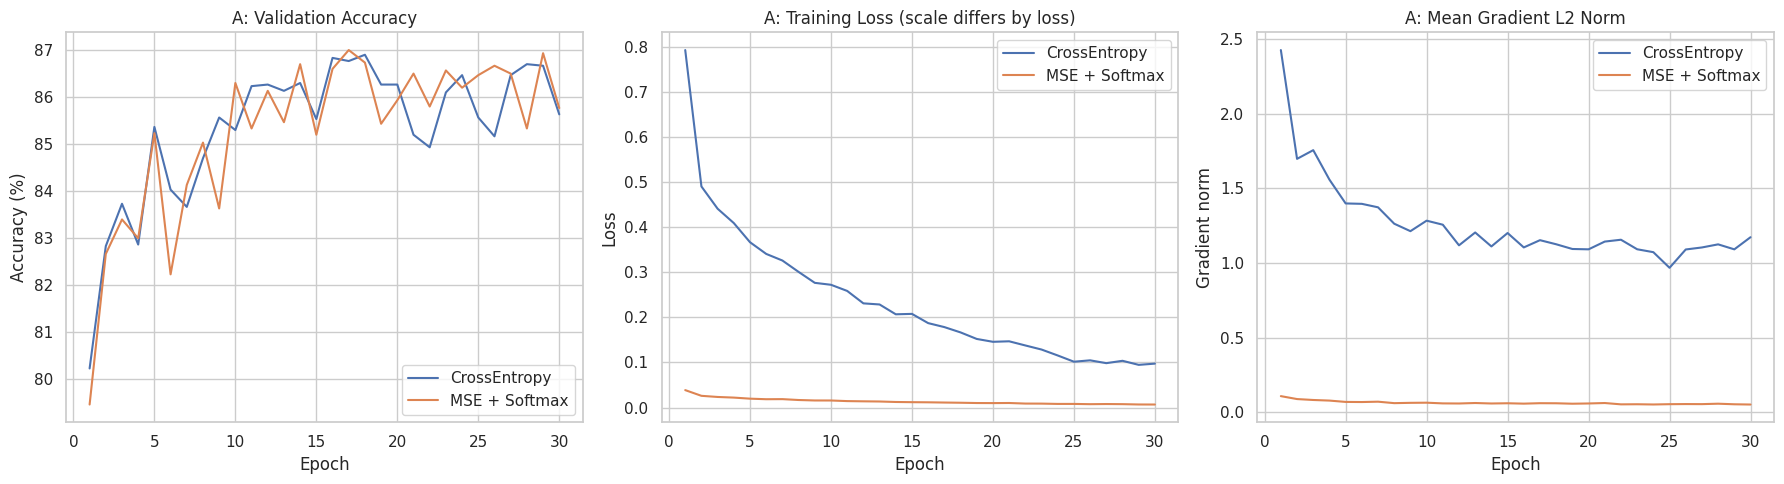

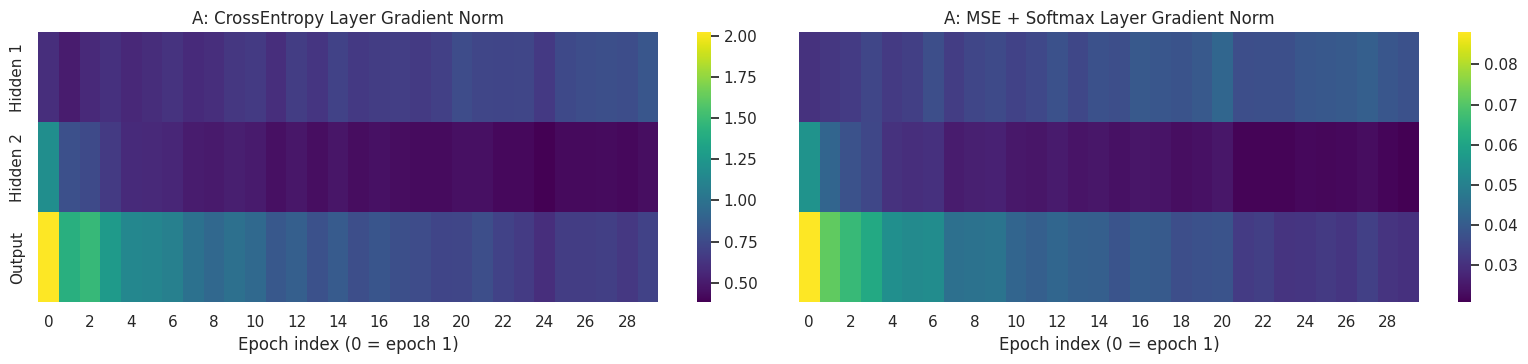

In [5]:
# 실험 A: 학습 곡선과 gradient norm 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for condition_name, history in a_histories.items():
    axes[0].plot(history['epoch'], history['val_accuracy'], label=condition_name)
    axes[1].plot(history['epoch'], history['train_loss'], label=condition_name)
    axes[2].plot(history['epoch'], history['gradient_norm'], label=condition_name)

axes[0].set_title('A: Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[1].set_title('A: Training Loss (scale differs by loss)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[2].set_title('A: Mean Gradient L2 Norm')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Gradient norm')
for axis in axes:
    axis.legend()
plt.tight_layout()
plt.show()

# 손실 함수별 layer gradient 흐름: 초기/후반 소실 정도를 heatmap으로 확인
fig, axes = plt.subplots(1, 2, figsize=(16, 3.8), sharey=True)
for axis, (condition_name, history) in zip(axes, a_histories.items()):
    gradient_flow = history[['grad_hidden_1', 'grad_hidden_2', 'grad_output']].T
    gradient_flow.index = ['Hidden 1', 'Hidden 2', 'Output']
    sns.heatmap(gradient_flow, ax=axis, cmap='viridis', cbar=True)
    axis.set_title(f'A: {condition_name} Layer Gradient Norm')
    axis.set_xlabel('Epoch index (0 = epoch 1)')
plt.tight_layout()
plt.show()

### 실험 A 실행 후 결과 분석 (실행 뒤 작성)

- 최종 테스트 정확도 비교:
- validation 정확도 수렴 속도 비교:
- loss 곡선의 안정성 비교 (손실 스케일 차이를 고려):
- gradient norm 및 layer별 gradient heatmap에서 본 초기/후반 차이:
- MSE에서 softmax가 필요한 이유에 대한 해설:
- 결론:

# 실험 B. 활성화 함수 비교: ReLU vs LeakyReLU vs Sigmoid

## 실험 조건

- 데이터셋: `make_moons` 비선형 2D 분류 데이터
- 네트워크: `2 -> 64 -> 64 -> 64 -> 2`
- 고정 요소: 동일 초기 가중치, 동일 mini-batch 순서, `CrossEntropyLoss`, `Adam(lr=0.01)`, `300` epochs
- 변경 요소: `ReLU`, `LeakyReLU(negative_slope=0.01)`, `Sigmoid`
- Dead ReLU 유도: 은닉층 weight를 `std=0.01`로 작게 초기화하고 bias를 음수로 설정

각 epoch에서 validation accuracy, layer별 gradient norm, 출력이 모든 train sample에서 정확히 0인 은닉 뉴런 비율을 기록한다. 또한 epoch `1`, `150`, `300`의 layer별 출력 분포를 저장하여 초기/중간/후반 activation 변화를 비교한다. LeakyReLU와 Sigmoid는 구조상 음수 입력에서도 출력이 정확히 0이 아니므로, exact-zero 지표는 특히 ReLU의 dead neuron을 계수하기 위한 것이다.

In [6]:
# make_moons 데이터 분할 및 표준화
X, y = make_moons(n_samples=1500, noise=0.18, random_state=SEED)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=SEED
)

moon_scaler = StandardScaler().fit(X_train)
X_train = moon_scaler.transform(X_train)
X_val = moon_scaler.transform(X_val)
X_test = moon_scaler.transform(X_test)

moon_train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
moon_val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))
moon_test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))
moon_train_features = torch.tensor(X_train, dtype=torch.float32)

def make_moon_loaders(shuffle_seed=SEED):
    loader_generator = torch.Generator().manual_seed(shuffle_seed)
    return (
        DataLoader(moon_train_ds, batch_size=32, shuffle=True, generator=loader_generator),
        DataLoader(moon_val_ds, batch_size=128, shuffle=False),
        DataLoader(moon_test_ds, batch_size=128, shuffle=False)
    )

class ActivationMLP(nn.Module):
    def __init__(self, activation_factory):
        super().__init__()
        self.hidden_layers = nn.ModuleList([
            nn.Linear(2, 64), nn.Linear(64, 64), nn.Linear(64, 64)
        ])
        self.activations = nn.ModuleList([activation_factory() for _ in range(3)])
        self.output_layer = nn.Linear(64, 2)

    def forward(self, x, return_hidden=False):
        pre_activations = []
        hidden_outputs = []
        for layer, activation in zip(self.hidden_layers, self.activations):
            z = layer(x)
            x = activation(z)
            pre_activations.append(z)
            hidden_outputs.append(x)
        logits = self.output_layer(x)
        if return_hidden:
            return logits, pre_activations, hidden_outputs
        return logits

def initialize_dead_relu_stress_test(model):
    for layer in model.hidden_layers:
        nn.init.normal_(layer.weight, mean=0.0, std=0.01)
        nn.init.constant_(layer.bias, -0.20)
    nn.init.normal_(model.output_layer.weight, mean=0.0, std=0.01)
    nn.init.zeros_(model.output_layer.bias)

activation_factories = {
    'ReLU': lambda: nn.ReLU(),
    'LeakyReLU': lambda: nn.LeakyReLU(negative_slope=0.01),
    'Sigmoid': lambda: nn.Sigmoid()
}

set_seed()
activation_template = ActivationMLP(activation_factories['ReLU'])
initialize_dead_relu_stress_test(activation_template)
activation_initial_state = copy.deepcopy(activation_template.state_dict())
print('make_moons split:', len(moon_train_ds), len(moon_val_ds), len(moon_test_ds))

make_moons split: 900 300 300


In [7]:
def evaluate_activation_model(model, data_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            logits = model(inputs)
            loss = criterion(logits, targets)
            running_loss += loss.item() * targets.size(0)
            correct += (logits.argmax(dim=1) == targets).sum().item()
            total += targets.size(0)
    return {'loss': running_loss / total, 'accuracy': 100.0 * correct / total}

def activation_diagnostics(model, features):
    model.eval()
    with torch.no_grad():
        _, pre_activations, hidden_outputs = model(features.to(device), return_hidden=True)
    diagnostics = {}
    output_arrays = []
    dead_masks = []
    for layer_index, (pre_activation, hidden_output) in enumerate(zip(pre_activations, hidden_outputs), start=1):
        dead_mask = (hidden_output == 0).all(dim=0)
        always_negative_mask = (pre_activation <= 0).all(dim=0)
        diagnostics[f'dead_zero_pct_layer_{layer_index}'] = 100.0 * dead_mask.float().mean().item()
        diagnostics[f'always_nonpositive_pct_layer_{layer_index}'] = 100.0 * always_negative_mask.float().mean().item()
        output_arrays.append(hidden_output.detach().cpu().numpy())
        dead_masks.append(dead_mask.detach().cpu().numpy())
    diagnostics['dead_zero_pct_mean'] = np.mean([
        diagnostics[f'dead_zero_pct_layer_{layer_index}'] for layer_index in range(1, 4)
    ])
    return diagnostics, output_arrays, dead_masks

def train_activation_condition(activation_name, activation_factory, epochs=300, learning_rate=0.01,
                               snapshot_epochs=(1, 150, 300)):
    train_loader, val_loader, test_loader = make_moon_loaders(shuffle_seed=SEED)
    model = ActivationMLP(activation_factory).to(device)
    model.load_state_dict(copy.deepcopy(activation_initial_state))
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    tracked_layers = {
        'grad_hidden_1': model.hidden_layers[0],
        'grad_hidden_2': model.hidden_layers[1],
        'grad_hidden_3': model.hidden_layers[2]
    }
    history = {
        'epoch': [], 'train_loss': [], 'val_loss': [], 'val_accuracy': [],
        'gradient_norm': [], 'dead_zero_pct_mean': [],
        'grad_hidden_1': [], 'grad_hidden_2': [], 'grad_hidden_3': []
    }
    activation_snapshots = {}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_grad_norm = 0.0
        layer_grad_norms = {name: 0.0 for name in tracked_layers}
        total = 0
        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, targets)
            loss.backward()
            batch_size = targets.size(0)
            running_grad_norm += gradient_l2_norm(model) * batch_size
            for layer_name, layer in tracked_layers.items():
                layer_grad_norms[layer_name] += module_gradient_l2_norm(layer) * batch_size
            optimizer.step()
            running_loss += loss.item() * batch_size
            total += batch_size

        validation = evaluate_activation_model(model, val_loader, criterion)
        diagnostics, _, _ = activation_diagnostics(model, moon_train_features)
        history['epoch'].append(epoch)
        history['train_loss'].append(running_loss / total)
        history['val_loss'].append(validation['loss'])
        history['val_accuracy'].append(validation['accuracy'])
        history['gradient_norm'].append(running_grad_norm / total)
        history['dead_zero_pct_mean'].append(diagnostics['dead_zero_pct_mean'])
        for layer_name in tracked_layers:
            history[layer_name].append(layer_grad_norms[layer_name] / total)
        if epoch in snapshot_epochs:
            _, snapshot_outputs, _ = activation_diagnostics(model, moon_train_features)
            activation_snapshots[epoch] = [values.copy() for values in snapshot_outputs]
        if epoch == 1 or epoch % 50 == 0 or epoch == epochs:
            print(
                f'{activation_name:>10s} | epoch {epoch:>3}/{epochs} | '
                f'train loss={history["train_loss"][-1]:.4f} | '
                f'val acc={validation["accuracy"]:.2f}% | '
                f'dead={diagnostics["dead_zero_pct_mean"]:.2f}%'
            )

    test_metrics = evaluate_activation_model(model, test_loader, criterion)
    final_diagnostics, hidden_outputs, dead_masks = activation_diagnostics(model, moon_train_features)
    return model, pd.DataFrame(history), test_metrics, final_diagnostics, hidden_outputs, dead_masks, activation_snapshots

In [8]:
B_EPOCHS = 300
B_LEARNING_RATE = 0.01
b_models = {}
b_histories = {}
b_test_results = {}
b_diagnostics = {}
b_hidden_outputs = {}
b_dead_masks = {}
b_activation_snapshots = {}

for activation_name, activation_factory in activation_factories.items():
    print(f'\n[B] Training: {activation_name}')
    model, history, test_metrics, diagnostics, hidden_outputs, dead_masks, snapshots = train_activation_condition(
        activation_name, activation_factory, epochs=B_EPOCHS, learning_rate=B_LEARNING_RATE
    )
    b_models[activation_name] = model
    b_histories[activation_name] = history
    b_test_results[activation_name] = test_metrics
    b_diagnostics[activation_name] = diagnostics
    b_hidden_outputs[activation_name] = hidden_outputs
    b_dead_masks[activation_name] = dead_masks
    b_activation_snapshots[activation_name] = snapshots

b_summary_rows = []
for activation_name, history in b_histories.items():
    diagnostics = b_diagnostics[activation_name]
    b_summary_rows.append({
        'Activation': activation_name,
        'Best Validation Accuracy (%)': history['val_accuracy'].max(),
        'Minimum Validation Loss': history['val_loss'].min(),
        'Epoch Reaching 90% Val Accuracy': first_epoch_reaching(history['val_accuracy'], 90.0),
        'Final Test Accuracy (%)': b_test_results[activation_name]['accuracy'],
        'Final Test Loss': b_test_results[activation_name]['loss'],
        'Final Gradient Norm': history['gradient_norm'].iloc[-1],
        'Dead Layer 1 (%)': diagnostics['dead_zero_pct_layer_1'],
        'Dead Layer 2 (%)': diagnostics['dead_zero_pct_layer_2'],
        'Dead Layer 3 (%)': diagnostics['dead_zero_pct_layer_3'],
        'Mean Dead Neuron (%)': diagnostics['dead_zero_pct_mean'],
    })

b_summary = pd.DataFrame(b_summary_rows).round(4)
display(b_summary)


[B] Training: ReLU
      ReLU | epoch   1/300 | train loss=0.6943 | val acc=50.00% | dead=100.00%
      ReLU | epoch  50/300 | train loss=0.6940 | val acc=50.00% | dead=100.00%
      ReLU | epoch 100/300 | train loss=0.6934 | val acc=50.00% | dead=100.00%
      ReLU | epoch 150/300 | train loss=0.6943 | val acc=50.00% | dead=100.00%
      ReLU | epoch 200/300 | train loss=0.6935 | val acc=50.00% | dead=100.00%
      ReLU | epoch 250/300 | train loss=0.6934 | val acc=50.00% | dead=100.00%
      ReLU | epoch 300/300 | train loss=0.6935 | val acc=50.00% | dead=100.00%

[B] Training: LeakyReLU
 LeakyReLU | epoch   1/300 | train loss=0.6945 | val acc=50.00% | dead=0.00%
 LeakyReLU | epoch  50/300 | train loss=0.0344 | val acc=96.67% | dead=0.00%
 LeakyReLU | epoch 100/300 | train loss=0.0319 | val acc=96.67% | dead=0.00%
 LeakyReLU | epoch 150/300 | train loss=0.0304 | val acc=95.67% | dead=0.00%
 LeakyReLU | epoch 200/300 | train loss=0.0359 | val acc=97.33% | dead=0.00%
 LeakyReLU | epoc

,Activation,Best Validation Accuracy (%),Minimum Validation Loss,Epoch Reaching 90% Val Accuracy,Final Test Accuracy (%),Final Test Loss,Final Gradient Norm,Dead Layer 1 (%),Dead Layer 2 (%),Dead Layer 3 (%),Mean Dead Neuron (%)
0,ReLU,50.0000,0.6931,NaN,50.0000,0.6932,0.0947,100.0,100.0,100.0,100.0
1,LeakyReLU,97.6667,0.0573,5.0,97.0000,0.2196,0.1456,0.0,0.0,0.0,0.0
2,Sigmoid,97.6667,0.0814,9.0,97.3333,0.1293,0.0808,0.0,0.0,0.0,0.0


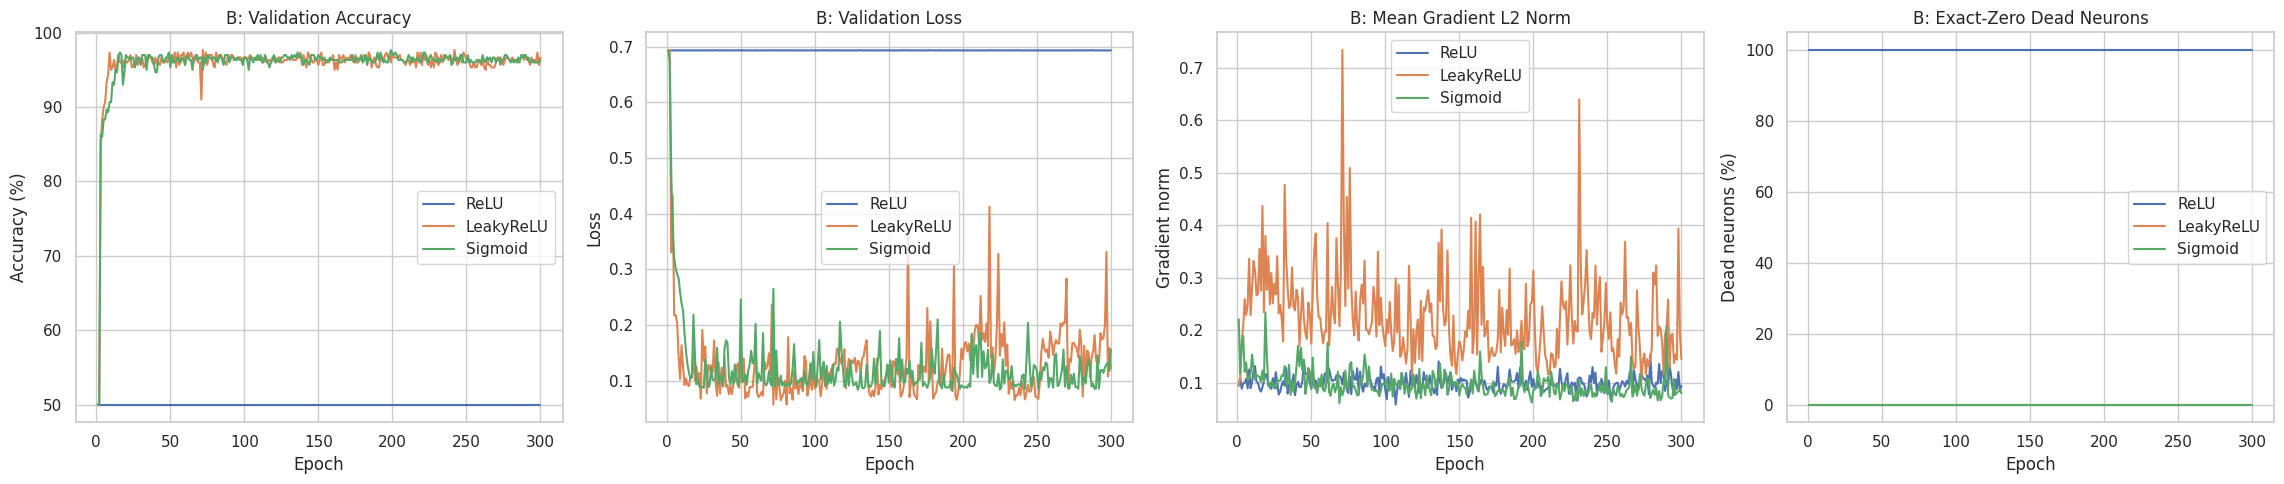

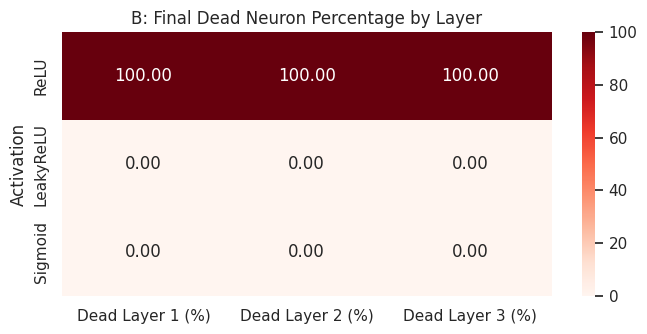

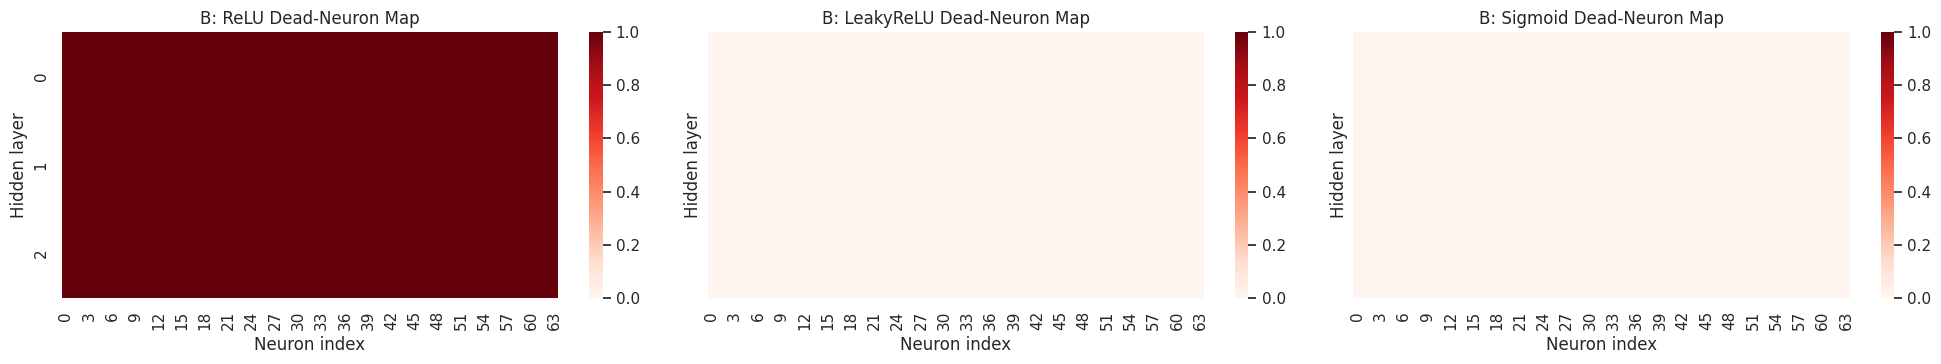

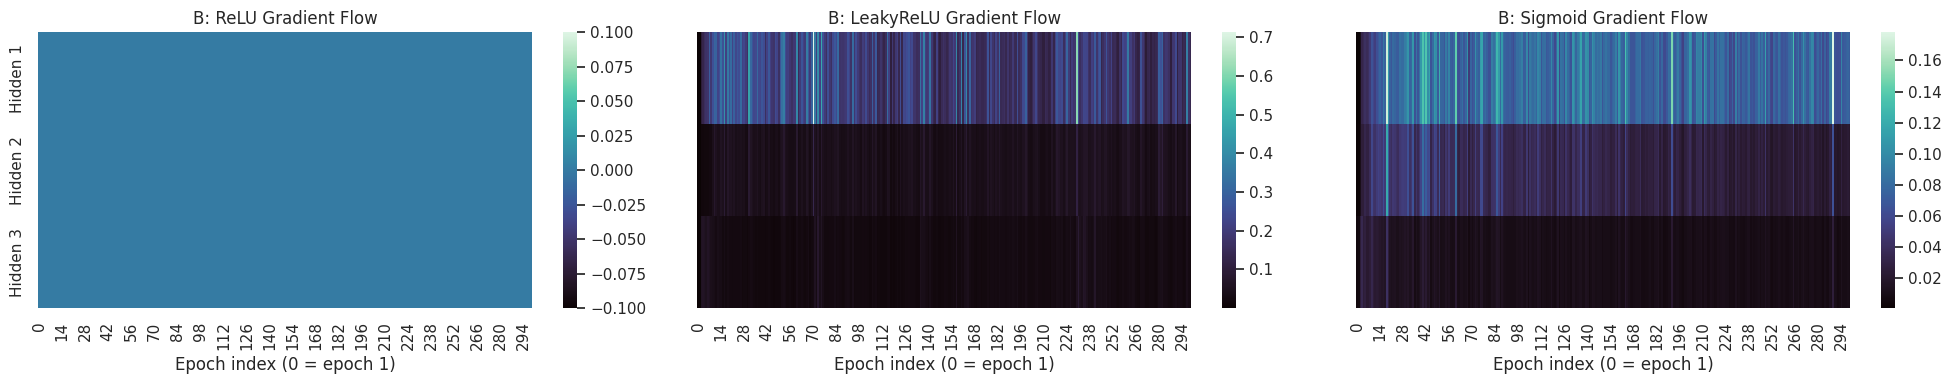

In [9]:
# 실험 B: 학습 정체, gradient 흐름, dead neuron 비율 곡선
fig, axes = plt.subplots(1, 4, figsize=(23, 5))
for activation_name, history in b_histories.items():
    axes[0].plot(history['epoch'], history['val_accuracy'], label=activation_name)
    axes[1].plot(history['epoch'], history['val_loss'], label=activation_name)
    axes[2].plot(history['epoch'], history['gradient_norm'], label=activation_name)
    axes[3].plot(history['epoch'], history['dead_zero_pct_mean'], label=activation_name)
axes[0].set_title('B: Validation Accuracy')
axes[0].set_ylabel('Accuracy (%)')
axes[1].set_title('B: Validation Loss')
axes[1].set_ylabel('Loss')
axes[2].set_title('B: Mean Gradient L2 Norm')
axes[2].set_ylabel('Gradient norm')
axes[3].set_title('B: Exact-Zero Dead Neurons')
axes[3].set_ylabel('Dead neurons (%)')
for axis in axes:
    axis.set_xlabel('Epoch')
    axis.legend()
plt.tight_layout()
plt.show()

# 최종 layer별 dead neuron 비율 heatmap
dead_percentage_table = b_summary.set_index('Activation')[
    ['Dead Layer 1 (%)', 'Dead Layer 2 (%)', 'Dead Layer 3 (%)']
]
plt.figure(figsize=(7, 3.5))
sns.heatmap(dead_percentage_table, annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=100)
plt.title('B: Final Dead Neuron Percentage by Layer')
plt.tight_layout()
plt.show()

# 개별 뉴런 단위 dead 상태 heatmap (1 = 모든 train sample에서 출력 0)
fig, axes = plt.subplots(1, 3, figsize=(20, 3.8), sharey=True)
for axis, activation_name in zip(axes, activation_factories.keys()):
    dead_neuron_map = np.vstack(b_dead_masks[activation_name]).astype(int)
    sns.heatmap(dead_neuron_map, ax=axis, cmap='Reds', vmin=0, vmax=1, cbar=True)
    axis.set_title(f'B: {activation_name} Dead-Neuron Map')
    axis.set_xlabel('Neuron index')
    axis.set_ylabel('Hidden layer')
plt.tight_layout()
plt.show()

# activation별 layer gradient heatmap: 어느 층/시점에서 gradient가 작아지는지 비교
fig, axes = plt.subplots(1, 3, figsize=(20, 4), sharey=True)
for axis, (activation_name, history) in zip(axes, b_histories.items()):
    gradient_flow = history[['grad_hidden_1', 'grad_hidden_2', 'grad_hidden_3']].T
    gradient_flow.index = ['Hidden 1', 'Hidden 2', 'Hidden 3']
    sns.heatmap(gradient_flow, ax=axis, cmap='mako', cbar=True)
    axis.set_title(f'B: {activation_name} Gradient Flow')
    axis.set_xlabel('Epoch index (0 = epoch 1)')
plt.tight_layout()
plt.show()

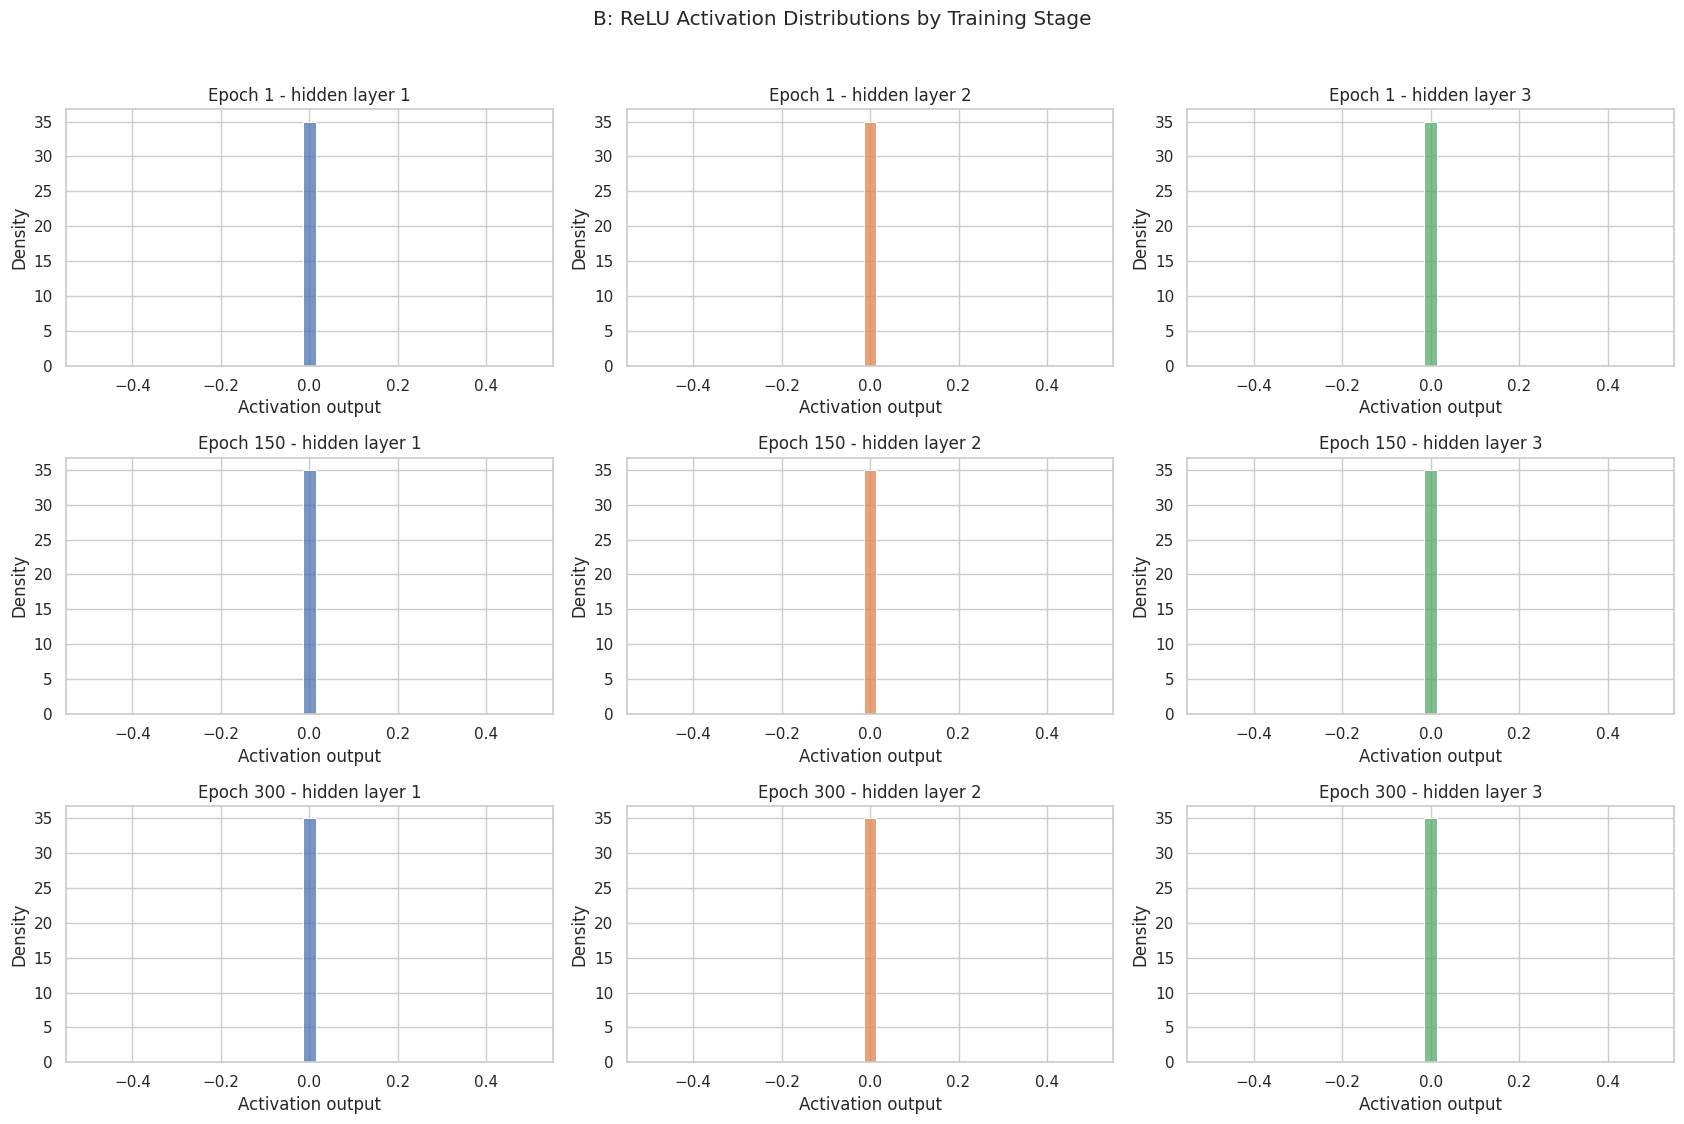

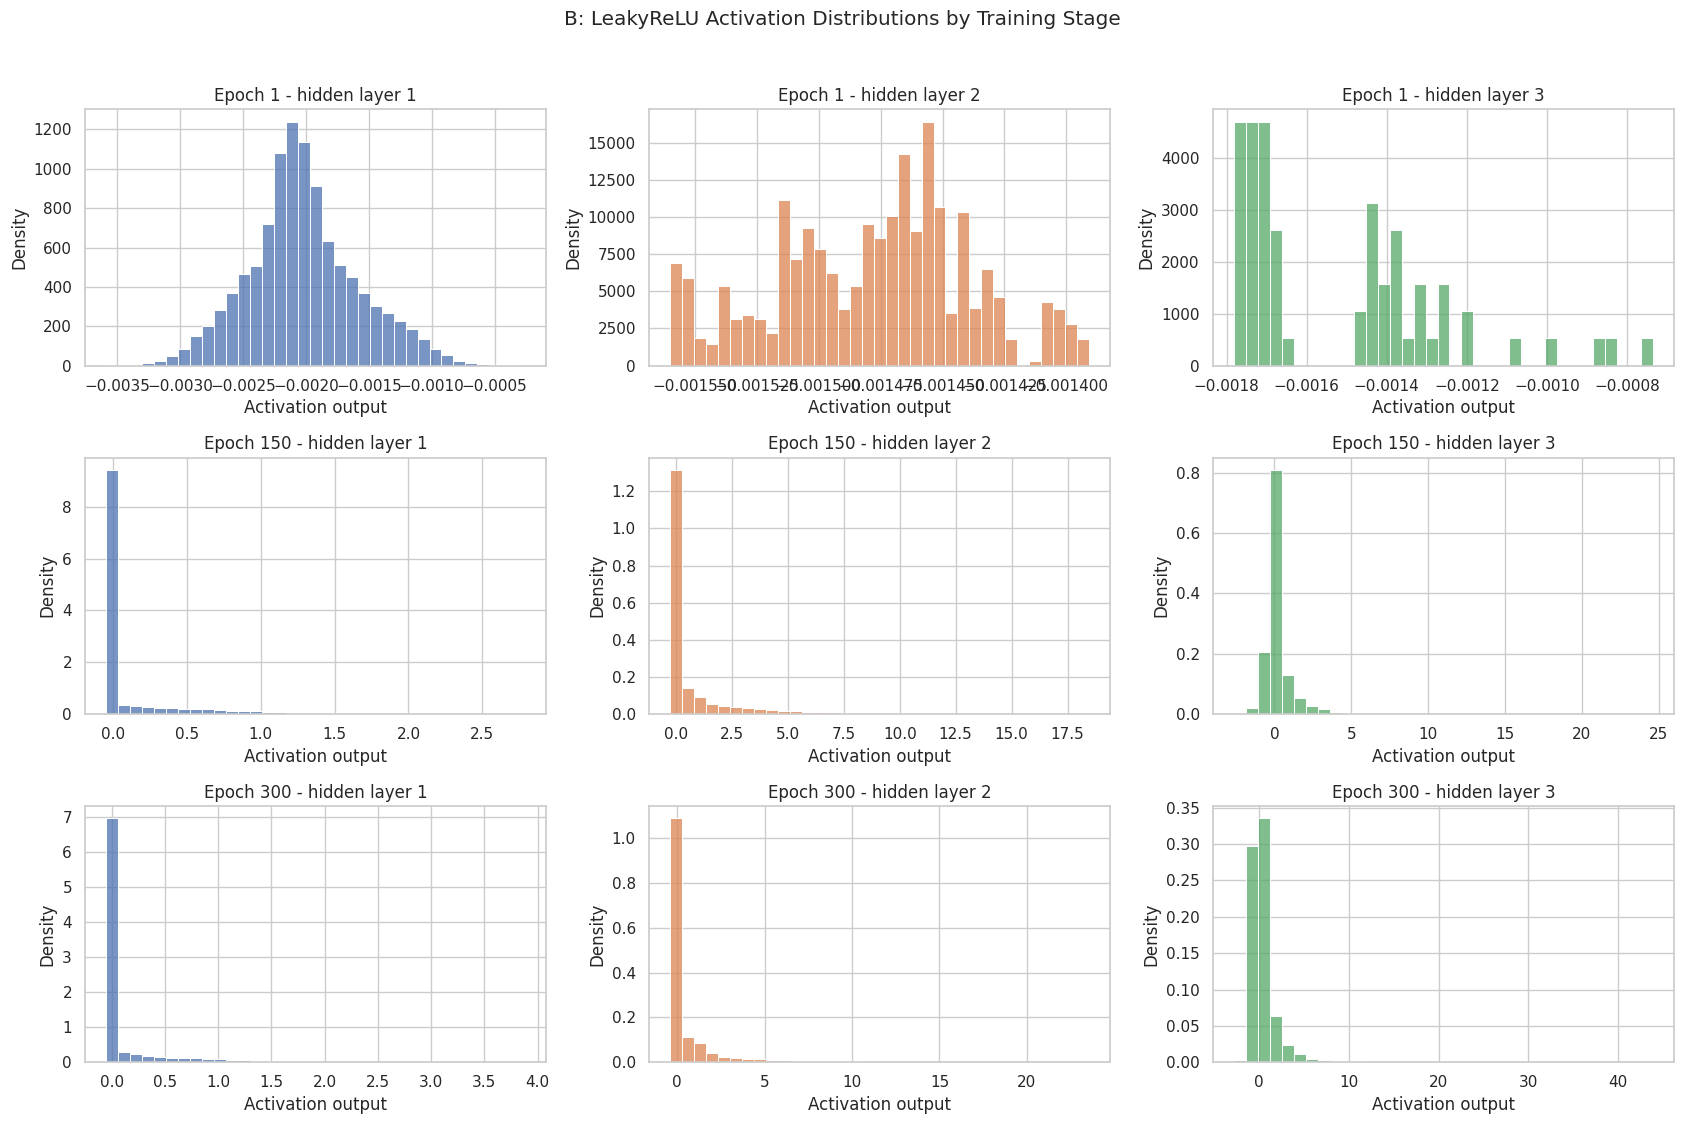

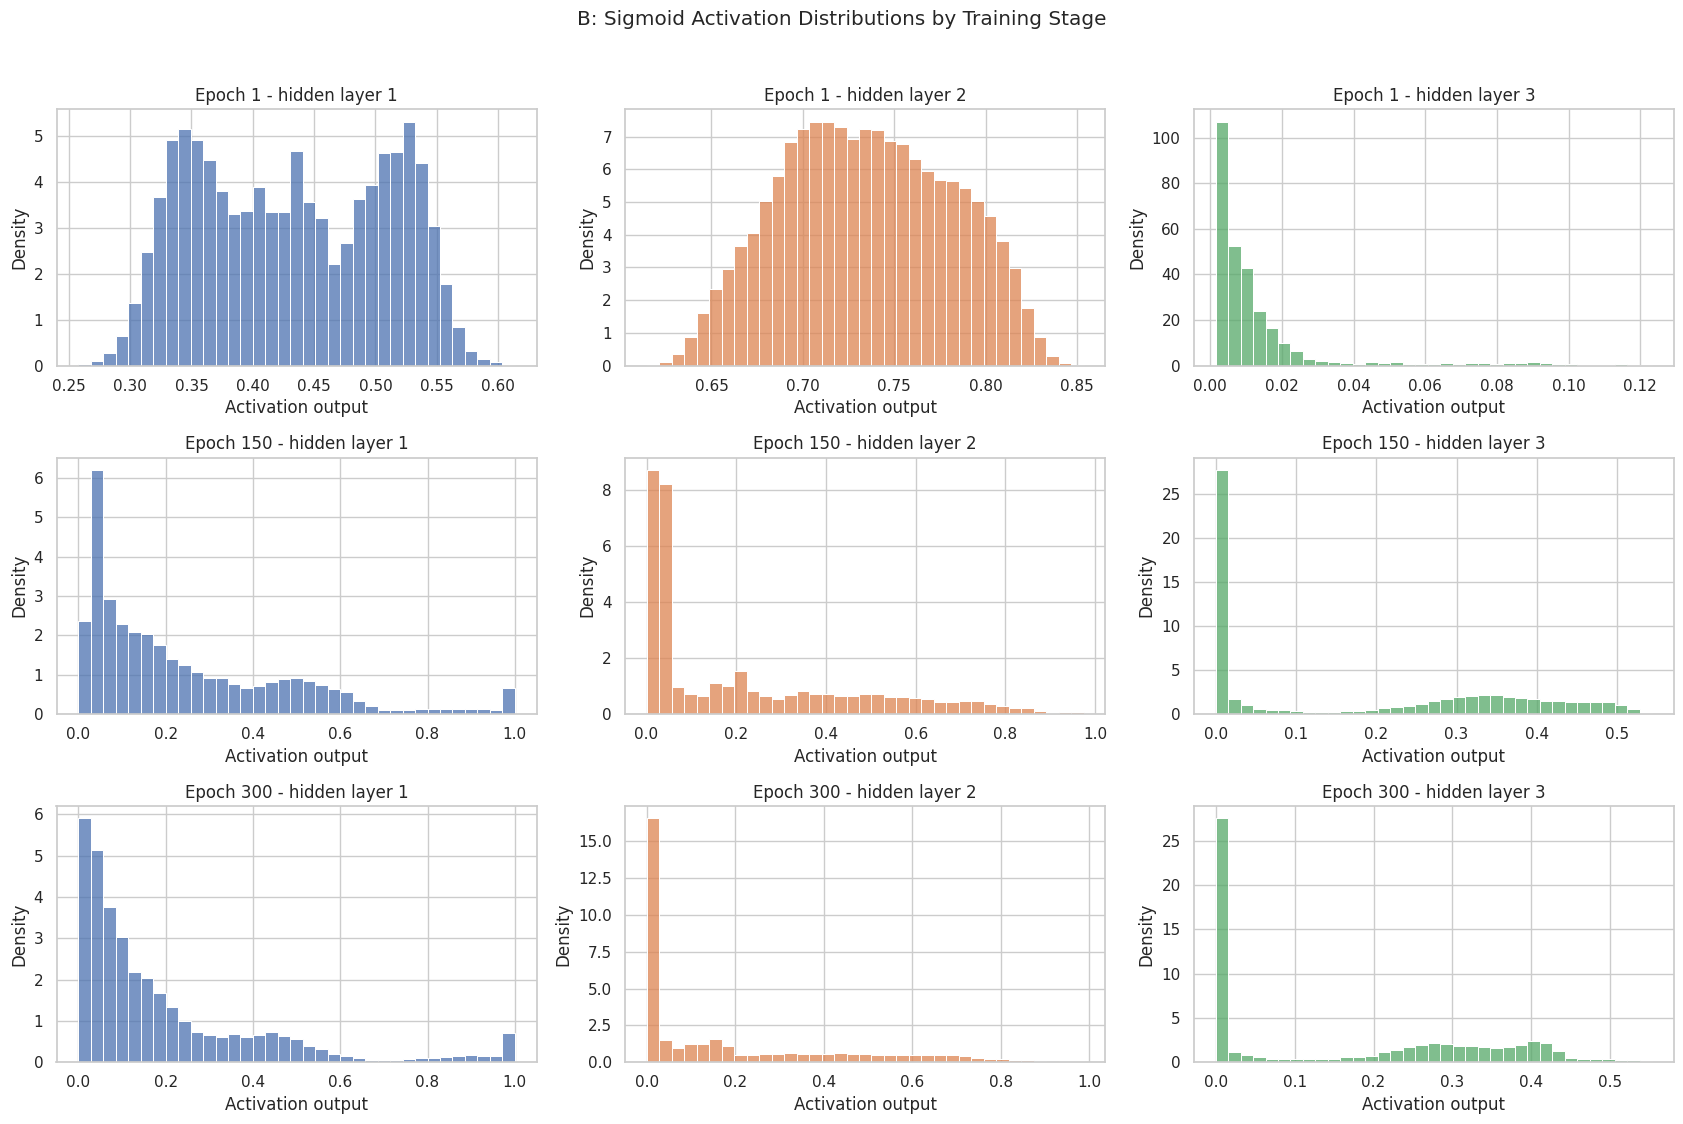

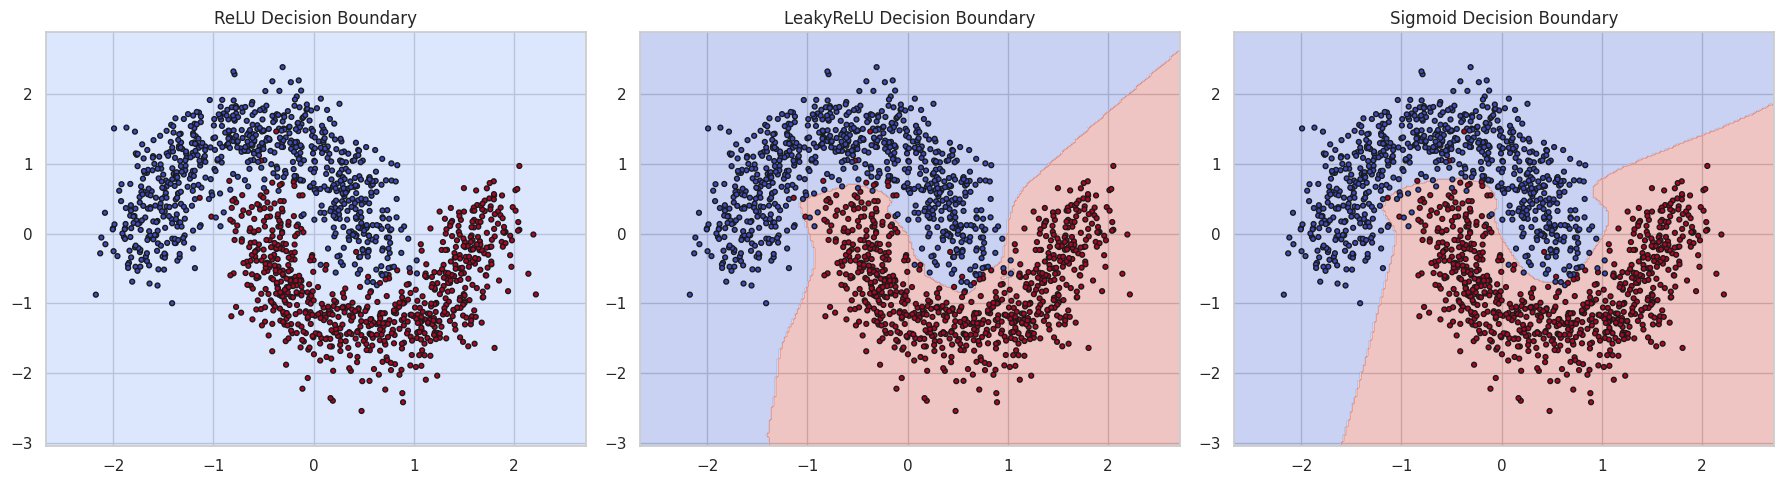

In [10]:
# 실험 B: 초반/중반/후반의 layer별 activation 출력 분포
snapshot_epochs = [1, B_EPOCHS // 2, B_EPOCHS]
for activation_name in activation_factories.keys():
    fig, axes = plt.subplots(3, 3, figsize=(17, 11))
    for row, epoch in enumerate(snapshot_epochs):
        for column in range(3):
            values = b_activation_snapshots[activation_name][epoch][column].ravel()
            sns.histplot(values, bins=35, stat='density', ax=axes[row, column], color=f'C{column}')
            axes[row, column].set_title(f'Epoch {epoch} - hidden layer {column + 1}')
            axes[row, column].set_xlabel('Activation output')
    plt.suptitle(f'B: {activation_name} Activation Distributions by Training Stage', y=1.02)
    plt.tight_layout()
    plt.show()

# 실험 B: 각 활성화 함수 모델의 결정 경계
all_scaled_features = np.vstack([X_train, X_val, X_test])
all_labels = np.concatenate([y_train, y_val, y_test])
x_min, x_max = all_scaled_features[:, 0].min() - 0.5, all_scaled_features[:, 0].max() + 0.5
y_min, y_max = all_scaled_features[:, 1].min() - 0.5, all_scaled_features[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, (activation_name, model) in zip(axes, b_models.items()):
    model.eval()
    with torch.no_grad():
        prediction = model(grid).argmax(dim=1).cpu().numpy().reshape(xx.shape)
    axis.contourf(xx, yy, prediction, alpha=0.30, cmap='coolwarm')
    axis.scatter(all_scaled_features[:, 0], all_scaled_features[:, 1], c=all_labels,
                 cmap='coolwarm', edgecolor='k', s=12)
    axis.set_title(f'{activation_name} Decision Boundary')
plt.tight_layout()
plt.show()

### 실험 B 실행 후 결과 분석 (실행 뒤 작성)

- 최종 테스트 정확도 및 loss 비교:
- ReLU의 layer별 dead neuron 수치와 학습 정체 여부:
- LeakyReLU가 dead neuron 현상을 완화한 정도:
- Sigmoid의 gradient norm 및 수렴 속도 분석:
- 초반/중반/후반 layer 출력 분포 변화에서 확인한 차이:
- layer별 gradient heatmap에서 gradient 소멸 구간 분석:
- 결정 경계에서 확인한 차이:
- 결론:

# 실험 C. 최적화 알고리즘 비교: SGD vs SGD+Momentum vs Adam

## 실험 조건

- 데이터셋과 모델: 실험 A와 동일한 Fashion-MNIST 및 `FashionMLP`
- 고정 요소: 동일 초기 가중치, 동일 mini-batch 순서, `CrossEntropyLoss`, `30` epochs
- 변경 요소: optimizer 종류와 초기 학습률 `0.1`, `0.01`, `0.001`
- 모든 조건에 `ExponentialLR(optimizer, gamma=0.9)`를 적용하여 매 epoch 학습률을 지수 감소시킨다.

학습률 `0.1`은 Adam에 클 수 있으나, 요구된 학습률 민감도 비교를 위해 의도적으로 포함한다. 정확도뿐 아니라 loss와 gradient norm 곡선을 통해 overshooting 또는 느린 수렴을 확인한다.

In [11]:
C_EPOCHS = 30
C_LEARNING_RATES = [0.1, 0.01, 0.001]
C_OPTIMIZERS = ['SGD', 'SGD+Momentum', 'Adam']
c_histories = {}
c_test_results = {}

for optimizer_name in C_OPTIMIZERS:
    for learning_rate in C_LEARNING_RATES:
        condition_name = f'{optimizer_name} (lr={learning_rate})'
        print(f'\n[C] Training: {condition_name}')
        train_loader, val_loader, test_loader = make_fashion_loaders(shuffle_seed=SEED)
        model = FashionMLP().to(device)
        model.load_state_dict(copy.deepcopy(fashion_initial_state))
        criterion = nn.CrossEntropyLoss()

        if optimizer_name == 'SGD':
            optimizer = optim.SGD(model.parameters(), lr=learning_rate)
        elif optimizer_name == 'SGD+Momentum':
            optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
        else:
            optimizer = optim.Adam(model.parameters(), lr=learning_rate)

        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
        history = train_fashion_condition(
            model, train_loader, val_loader, criterion, 'ce', optimizer,
            epochs=C_EPOCHS, scheduler=scheduler, print_every=10
        )
        test_metrics = evaluate_fashion_model(model, test_loader, criterion, 'ce')
        c_histories[condition_name] = history
        c_test_results[condition_name] = test_metrics

c_summary_rows = []
for optimizer_name in C_OPTIMIZERS:
    for learning_rate in C_LEARNING_RATES:
        condition_name = f'{optimizer_name} (lr={learning_rate})'
        history = c_histories[condition_name]
        c_summary_rows.append({
            'Optimizer': optimizer_name,
            'Initial LR': learning_rate,
            'Best Validation Accuracy (%)': history['val_accuracy'].max(),
            'Best Validation Epoch': int(history.loc[history['val_accuracy'].idxmax(), 'epoch']),
            'Minimum Validation Loss': history['val_loss'].min(),
            'Epoch Reaching 80% Val Accuracy': first_epoch_reaching(history['val_accuracy'], 80.0),
            'Final Test Accuracy (%)': c_test_results[condition_name]['accuracy'],
            'Final Test Loss': c_test_results[condition_name]['loss'],
            'Final Train Loss': history['train_loss'].iloc[-1],
            'Final Gradient Norm': history['gradient_norm'].iloc[-1],
            'Last 5 Val Accuracy Std': history['val_accuracy'].tail(5).std()
        })

c_summary = pd.DataFrame(c_summary_rows).round(4)
display(c_summary)
print('\nFinal Test Accuracy Pivot Table (%)')
display(c_summary.pivot(index='Optimizer', columns='Initial LR', values='Final Test Accuracy (%)'))


[C] Training: SGD (lr=0.1)
Epoch  1/30 | lr=0.10000 | train loss=1.1316 | val acc=74.53%
Epoch 10/30 | lr=0.03874 | train loss=0.3755 | val acc=84.70%
Epoch 20/30 | lr=0.01351 | train loss=0.3150 | val acc=86.03%
Epoch 30/30 | lr=0.00471 | train loss=0.2954 | val acc=86.37%

[C] Training: SGD (lr=0.01)
Epoch  1/30 | lr=0.01000 | train loss=2.1639 | val acc=53.67%
Epoch 10/30 | lr=0.00387 | train loss=0.7012 | val acc=74.53%
Epoch 20/30 | lr=0.00135 | train loss=0.6276 | val acc=77.07%
Epoch 30/30 | lr=0.00047 | train loss=0.6088 | val acc=77.47%

[C] Training: SGD (lr=0.001)
Epoch  1/30 | lr=0.00100 | train loss=2.2891 | val acc=10.63%
Epoch 10/30 | lr=0.00039 | train loss=2.1303 | val acc=49.87%
Epoch 20/30 | lr=0.00014 | train loss=2.0310 | val acc=51.93%
Epoch 30/30 | lr=0.00005 | train loss=1.9895 | val acc=52.60%

[C] Training: SGD+Momentum (lr=0.1)
Epoch  1/30 | lr=0.10000 | train loss=0.9134 | val acc=72.97%
Epoch 10/30 | lr=0.03874 | train loss=0.2470 | val acc=85.57%
Epoch 20

,Optimizer,Initial LR,Best Validation Accuracy (%),Best Validation Epoch,Minimum Validation Loss,Epoch Reaching 80% Val Accuracy,Final Test Accuracy (%),Final Test Loss,Final Train Loss,Final Gradient Norm,Last 5 Val Accuracy Std
0,SGD,0.100,86.4000,27,0.3764,4.0,85.32,0.4127,0.2954,1.2329,0.1225
1,SGD,0.010,77.5333,29,0.6164,NaN,77.39,0.6265,0.6088,1.2306,0.1027
2,SGD,0.001,52.6000,30,1.9933,NaN,53.28,1.9907,1.9895,0.8909,0.0901
3,SGD+Momentum,0.100,87.7333,22,0.3830,2.0,86.54,0.5183,0.0793,0.6985,0.2290
4,SGD+Momentum,0.010,86.2667,24,0.3821,2.0,85.17,0.4160,0.2972,1.3648,0.2060
5,SGD+Momentum,0.001,77.3000,30,0.6213,NaN,77.24,0.6310,0.6140,1.2311,0.1304
6,Adam,0.100,55.1667,30,1.0763,NaN,56.40,1.0479,0.9756,0.6775,0.9665
7,Adam,0.010,87.2667,25,0.4019,2.0,86.16,0.6699,0.0476,0.4236,0.3185
8,Adam,0.001,87.7000,29,0.3584,1.0,86.53,0.4049,0.1636,1.0343,0.1300



Final Test Accuracy Pivot Table (%)


Initial LR,0.001,0.010,0.100
Optimizer,,,
Adam,86.53,86.16,56.40
SGD,53.28,77.39,85.32
SGD+Momentum,77.24,85.17,86.54


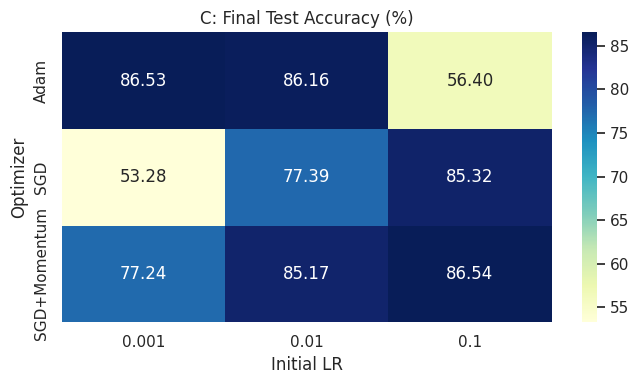

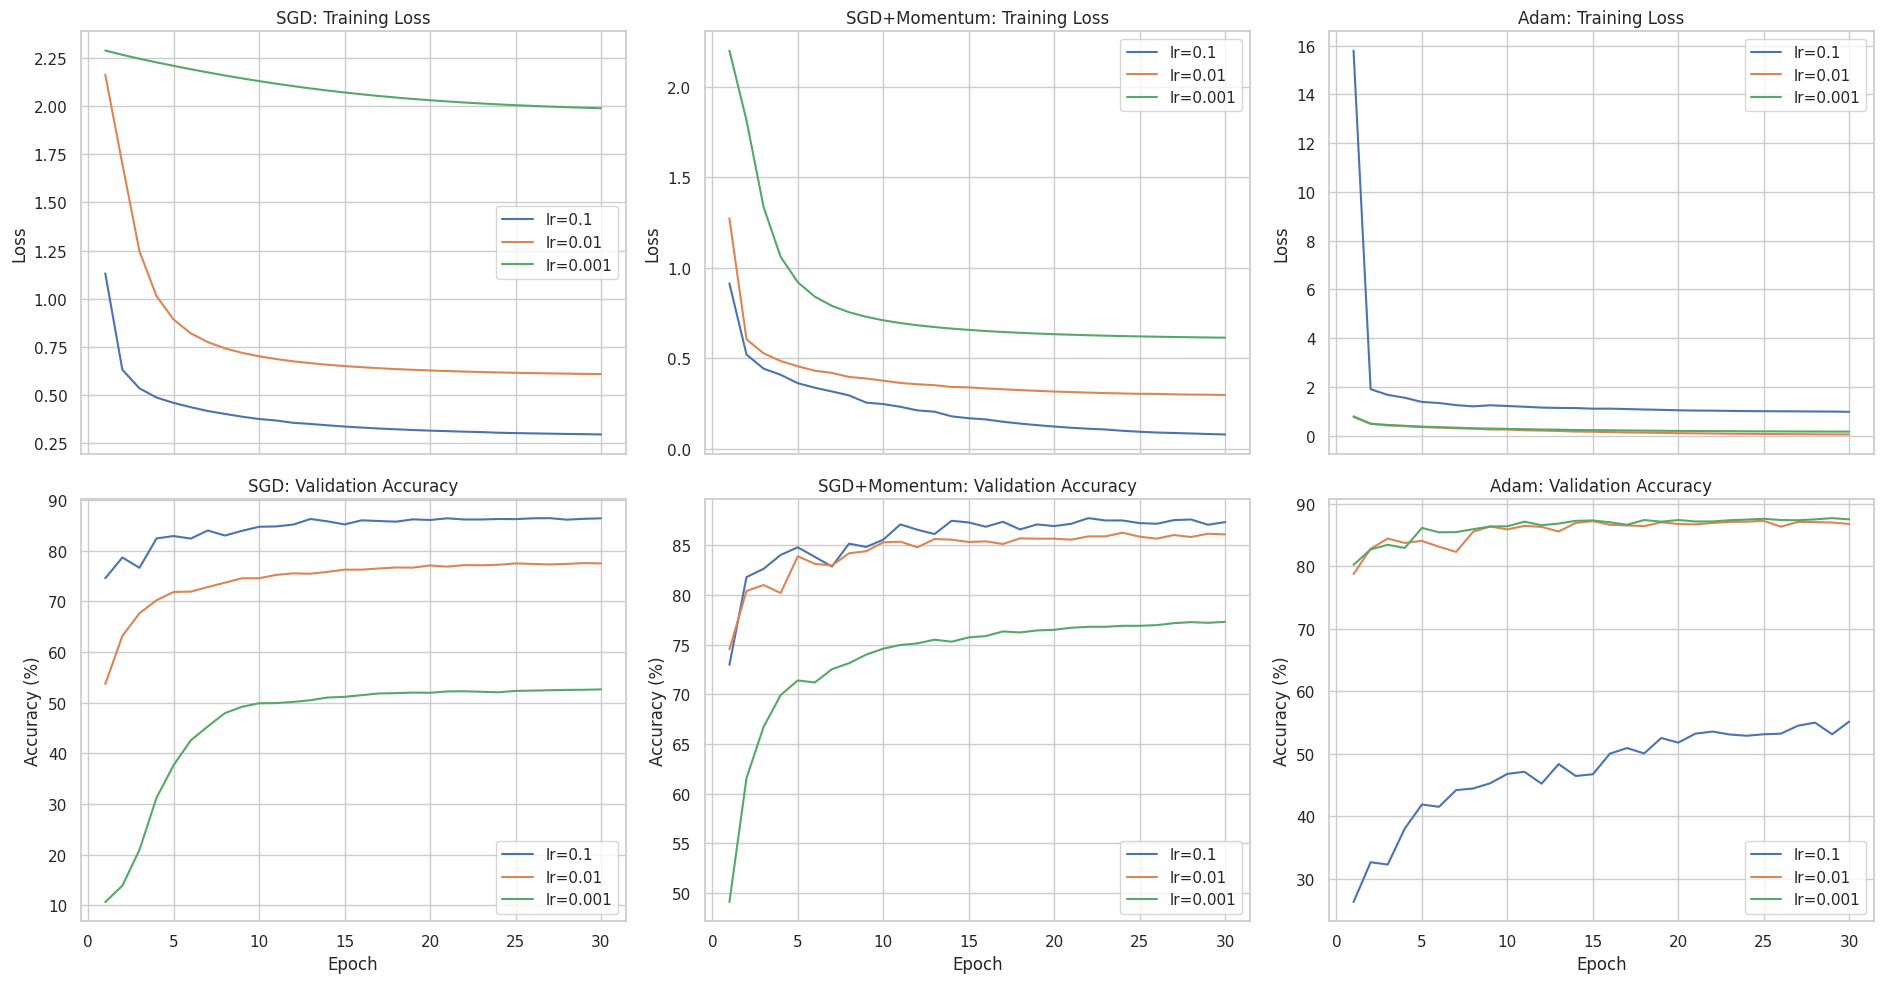

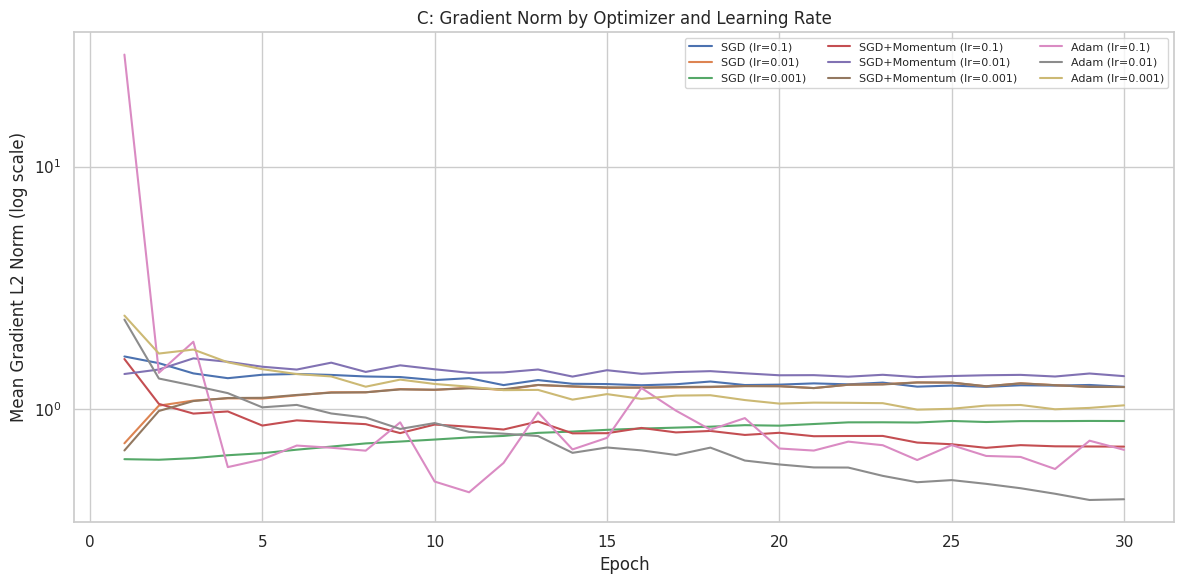

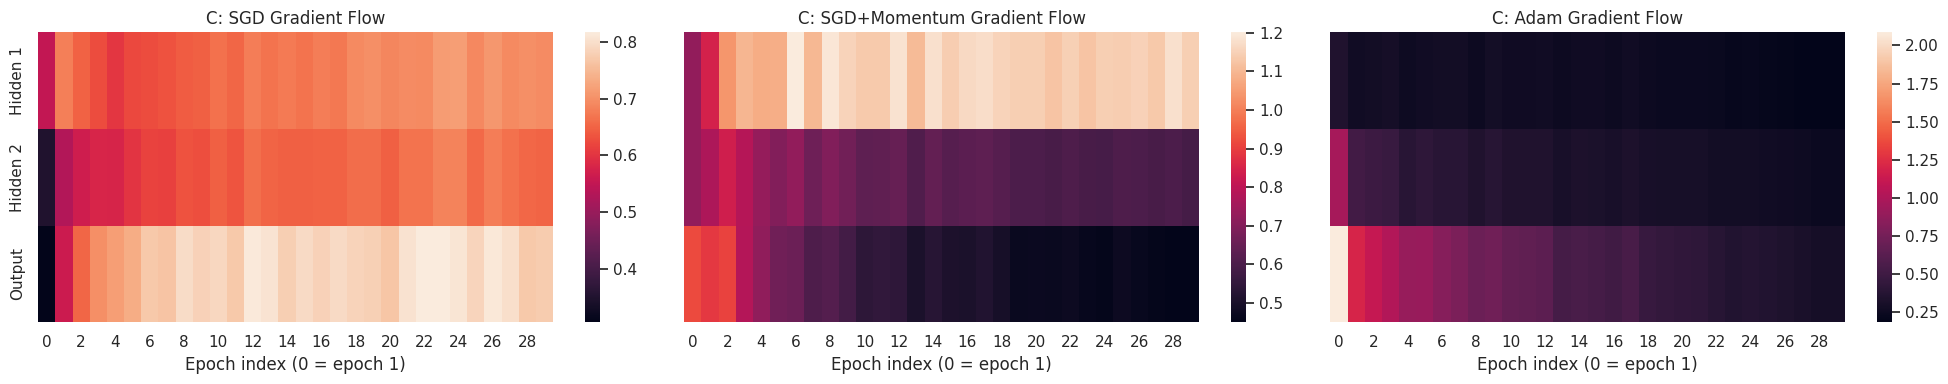

In [12]:
# 실험 C: 결과 heatmap
accuracy_pivot = c_summary.pivot(index='Optimizer', columns='Initial LR', values='Final Test Accuracy (%)')
plt.figure(figsize=(7, 4))
sns.heatmap(accuracy_pivot, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('C: Final Test Accuracy (%)')
plt.tight_layout()
plt.show()

# 실험 C: optimizer별 초기 학습률에 따른 loss와 validation accuracy 곡선
fig, axes = plt.subplots(2, 3, figsize=(19, 10), sharex=True)
for column, optimizer_name in enumerate(C_OPTIMIZERS):
    for learning_rate in C_LEARNING_RATES:
        condition_name = f'{optimizer_name} (lr={learning_rate})'
        history = c_histories[condition_name]
        axes[0, column].plot(history['epoch'], history['train_loss'], label=f'lr={learning_rate}')
        axes[1, column].plot(history['epoch'], history['val_accuracy'], label=f'lr={learning_rate}')
    axes[0, column].set_title(f'{optimizer_name}: Training Loss')
    axes[1, column].set_title(f'{optimizer_name}: Validation Accuracy')
    axes[0, column].set_ylabel('Loss')
    axes[1, column].set_ylabel('Accuracy (%)')
    axes[1, column].set_xlabel('Epoch')
    axes[0, column].legend()
    axes[1, column].legend()
plt.tight_layout()
plt.show()

# 실험 C: gradient 흐름 비교
plt.figure(figsize=(12, 6))
for condition_name, history in c_histories.items():
    plt.plot(history['epoch'], history['gradient_norm'], label=condition_name)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Mean Gradient L2 Norm (log scale)')
plt.title('C: Gradient Norm by Optimizer and Learning Rate')
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

# 동일한 대표 학습률(lr=0.01)에서 optimizer별 layer gradient 흐름 비교
fig, axes = plt.subplots(1, 3, figsize=(20, 4), sharey=True)
for axis, optimizer_name in zip(axes, C_OPTIMIZERS):
    condition_name = f'{optimizer_name} (lr=0.01)'
    history = c_histories[condition_name]
    gradient_flow = history[['grad_hidden_1', 'grad_hidden_2', 'grad_output']].T
    gradient_flow.index = ['Hidden 1', 'Hidden 2', 'Output']
    sns.heatmap(gradient_flow, ax=axis, cmap='rocket', cbar=True)
    axis.set_title(f'C: {optimizer_name} Gradient Flow')
    axis.set_xlabel('Epoch index (0 = epoch 1)')
plt.tight_layout()
plt.show()

## 실험 C-추가. Exponential Decay 효과 확인

주 실험 C는 요구사항에 따라 모든 조건에 exponential decay를 적용한다. decay 자체가 학습 후반 안정성에 미친 영향을 확인하기 위해, 대표 조건인 `SGD+Momentum(lr=0.01)`에 대해 **decay 사용/미사용**을 같은 초기 가중치와 데이터 순서에서 추가 비교한다.


[C-extra] Training: SGD+Momentum (lr=0.01) WITHOUT Exponential Decay
Epoch  1/30 | lr=0.01000 | train loss=1.2732 | val acc=74.53%
Epoch 10/30 | lr=0.01000 | train loss=0.3505 | val acc=85.53%
Epoch 20/30 | lr=0.01000 | train loss=0.2392 | val acc=86.50%
Epoch 30/30 | lr=0.01000 | train loss=0.1715 | val acc=85.90%


,Condition,Best Validation Accuracy (%),Final Test Accuracy (%),Final Test Loss,Final Learning Rate
0,With Exponential Decay,86.26667,85.17,0.41604,0.00047
1,Without Decay,86.66667,85.74,0.44862,0.01000


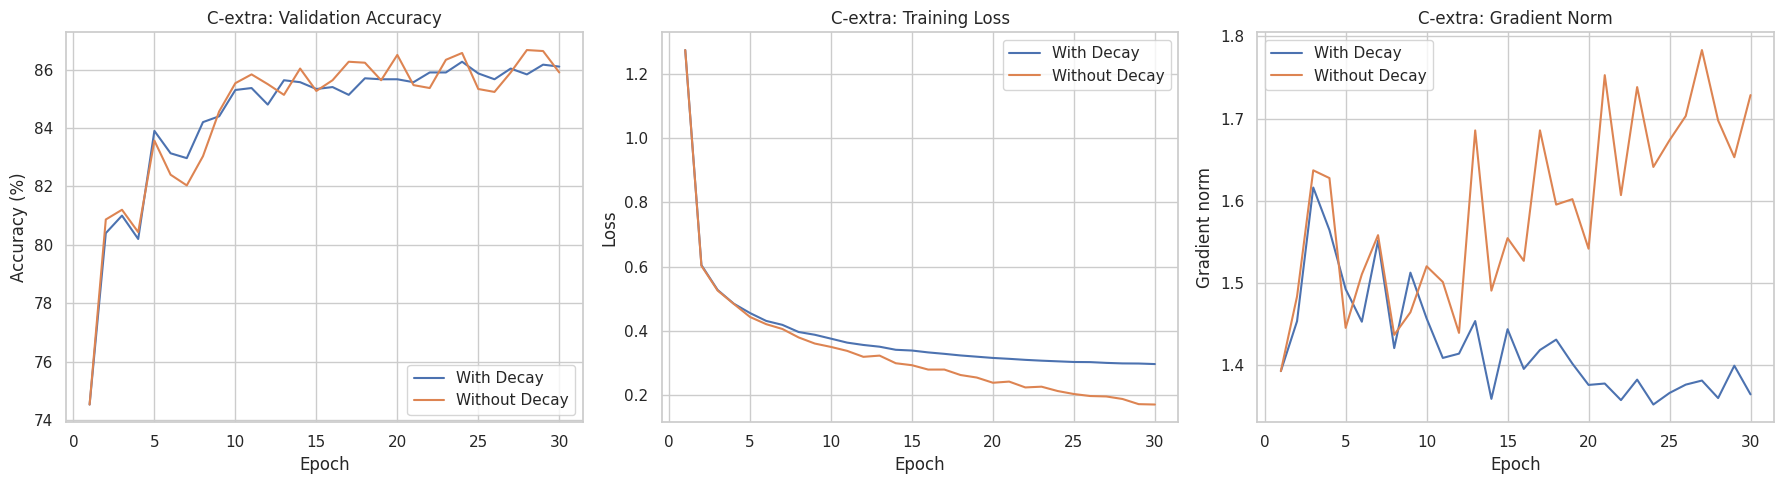

In [13]:
decay_reference_condition = 'SGD+Momentum (lr=0.01)'
history_with_decay = c_histories[decay_reference_condition]
test_with_decay = c_test_results[decay_reference_condition]

print('\n[C-extra] Training: SGD+Momentum (lr=0.01) WITHOUT Exponential Decay')
train_loader, val_loader, test_loader = make_fashion_loaders(shuffle_seed=SEED)
model_no_decay = FashionMLP().to(device)
model_no_decay.load_state_dict(copy.deepcopy(fashion_initial_state))
criterion = nn.CrossEntropyLoss()
optimizer_no_decay = optim.SGD(model_no_decay.parameters(), lr=0.01, momentum=0.9)
history_no_decay = train_fashion_condition(
    model_no_decay, train_loader, val_loader, criterion, 'ce', optimizer_no_decay,
    epochs=C_EPOCHS, scheduler=None, print_every=10
)
test_no_decay = evaluate_fashion_model(model_no_decay, test_loader, criterion, 'ce')

decay_comparison = pd.DataFrame([
    {
        'Condition': 'With Exponential Decay',
        'Best Validation Accuracy (%)': history_with_decay['val_accuracy'].max(),
        'Final Test Accuracy (%)': test_with_decay['accuracy'],
        'Final Test Loss': test_with_decay['loss'],
        'Final Learning Rate': history_with_decay['lr'].iloc[-1]
    },
    {
        'Condition': 'Without Decay',
        'Best Validation Accuracy (%)': history_no_decay['val_accuracy'].max(),
        'Final Test Accuracy (%)': test_no_decay['accuracy'],
        'Final Test Loss': test_no_decay['loss'],
        'Final Learning Rate': history_no_decay['lr'].iloc[-1]
    }
]).round(5)
display(decay_comparison)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for label, history in [('With Decay', history_with_decay), ('Without Decay', history_no_decay)]:
    axes[0].plot(history['epoch'], history['val_accuracy'], label=label)
    axes[1].plot(history['epoch'], history['train_loss'], label=label)
    axes[2].plot(history['epoch'], history['gradient_norm'], label=label)
axes[0].set_title('C-extra: Validation Accuracy')
axes[1].set_title('C-extra: Training Loss')
axes[2].set_title('C-extra: Gradient Norm')
axes[0].set_ylabel('Accuracy (%)')
axes[1].set_ylabel('Loss')
axes[2].set_ylabel('Gradient norm')
for axis in axes:
    axis.set_xlabel('Epoch')
    axis.legend()
plt.tight_layout()
plt.show()

### 실험 C 실행 후 결과 분석 (실행 뒤 작성)

- optimizer 및 learning rate별 최종 테스트 정확도 표 해석:
- SGD의 느린 수렴 또는 overshooting 관찰 결과:
- Momentum이 SGD와 비교하여 보인 변화:
- Adam의 학습률 민감도 및 안정성:
- Exponential Decay 사용/미사용 보조 실험의 성능과 안정성 비교:
- optimizer별 layer gradient heatmap에서 관찰한 흐름:
- 결론:

# 최종 실험 결과 보고서 (모든 셀 실행 뒤 작성)

## 1. 실험 설정 요약

- 사용 데이터셋과 데이터 분할:
- 사용 네트워크 구조:
- 비교 공정성을 위한 통제 방법:

## 2. 정량 결과 요약

- 실험 A 핵심 결과:
- 실험 B 핵심 결과:
- 실험 C 핵심 결과:

## 3. 종합 분석

- 손실 함수가 학습 결과에 미친 영향:
- 활성화 함수가 gradient 흐름과 dead neuron에 미친 영향:
- optimizer와 learning rate가 수렴 속도 및 안정성에 미친 영향:

## 4. 결론 및 한계

- 최종 결론:
- 실험 한계 및 추가 실험 제안: